In [2]:
import os, h5py, numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [3]:
IMG_DIR  = "TrainData/img"
MASK_DIR = "TrainData/mask"

img_files  = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f"Images found : {len(img_files)}")
print(f"Masks  found : {len(mask_files)}")
print(f"First image  : {img_files[0]}")
print(f"First mask   : {mask_files[0]}")

# Sanity check — filenames must match

#assert img_files == mask_files, "Mismatch between img and mask filenames!"
#print("\n✓ All filenames match")

Images found : 3799
Masks  found : 3799
First image  : image_1.h5
First mask   : mask_1.h5


In [4]:
import os, h5py, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

IMG_DIR  = "TrainData/img"
MASK_DIR = "TrainData/mask"
IMG_SIZE = 64

IMG_KEYS  = ['img', 'image', 'data', 'sen2', 'x', 'X']
MASK_KEYS = ['mask', 'label', 'gt', 'y', 'Y']

def read_h5(path, keys):
    with h5py.File(path, 'r') as f:
        for k in keys:
            if k in f:
                return f[k][:]
        # fallback: first dataset found
        for k in f.keys():
            if hasattr(f[k], 'shape'):
                return f[k][:]
    raise KeyError(f"No array in {path}")

img_files  = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

images, labels = [], []
errors = []

for i, (ifn, mfn) in enumerate(zip(img_files, mask_files)):
    try:
        img  = read_h5(os.path.join(IMG_DIR,  ifn),  IMG_KEYS).astype(np.float32)
        mask = read_h5(os.path.join(MASK_DIR, mfn), MASK_KEYS)

        # ── fix image orientation ──────────────────────────────────
        if img.ndim == 3:
            # channels first → last
            if img.shape[0] < img.shape[1]:
                img = np.transpose(img, (1, 2, 0))
            # pick 3 bands
            if img.shape[-1] >= 4:
                img = img[:, :, [3, 2, 1]]
            elif img.shape[-1] < 3:
                img = np.stack([img[:,:,0]]*3, axis=-1)
        elif img.ndim == 2:
            img = np.stack([img]*3, axis=-1)

        # ── fix mask ───────────────────────────────────────────────
        mask = mask.squeeze()
        if mask.ndim > 2:
            mask = mask[0]

        # ── label: 1 if >1% of pixels are landslide ───────────────
        # (avoids 1 stray pixel flipping the whole label)
        landslide_ratio = (mask > 0).sum() / mask.size
        label = 1 if landslide_ratio > 0.01 else 0

        images.append(img)
        labels.append(label)

    except Exception as e:
        errors.append(ifn)
        if len(errors) <= 3:
            print(f"[skip] {ifn}: {e}")

    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(img_files)} loaded...")

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int32)

print(f"\n✓ Loaded  : {len(images)} samples  ({len(errors)} skipped)")
print(f"  Landslide: {labels.sum()}  ({labels.mean()*100:.1f}%)")
print(f"  No slide : {(labels==0).sum()}  ({(1-labels.mean())*100:.1f}%)")
print(f"  Raw pixel range: [{images.min():.2f}, {images.max():.2f}]")

  500/3799 loaded...
  1000/3799 loaded...
  1500/3799 loaded...
  2000/3799 loaded...
  2500/3799 loaded...
  3000/3799 loaded...
  3500/3799 loaded...

✓ Loaded  : 3799 samples  (0 skipped)
  Landslide: 1463  (38.5%)
  No slide : 2336  (61.5%)
  Raw pixel range: [0.00, 33.16]


Shape        : (3799, 64, 64, 3)
Pixel range  : [0.0000, 1.0000]
Mean per-img std: 0.1358


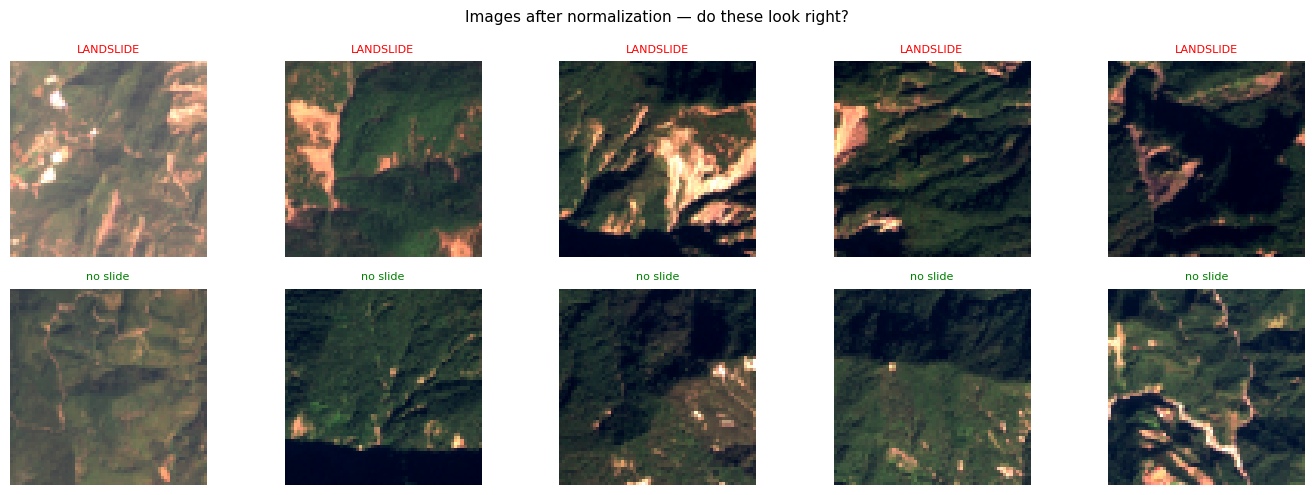

In [5]:
# Replace NaN / Inf
images = np.nan_to_num(images, nan=0.0, posinf=0.0, neginf=0.0)

# Global percentile clip → prevents a few extreme pixels
# from crushing everything else to near-zero
p2  = np.percentile(images, 2)
p98 = np.percentile(images, 98)
images = np.clip(images, p2, p98)

# Normalize to [0, 1]
images = (images - p2) / (p98 - p2 + 1e-8)
images = images.astype(np.float32)

# Resize
images = tf.image.resize(images, [IMG_SIZE, IMG_SIZE]).numpy()

print(f"Shape        : {images.shape}")
print(f"Pixel range  : [{images.min():.4f}, {images.max():.4f}]")
print(f"Mean per-img std: "
      f"{images.reshape(len(images),-1).std(axis=1).mean():.4f}")

# Verify images look correct
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
ls_idx    = np.where(labels == 1)[0][:5]
no_ls_idx = np.where(labels == 0)[0][:5]
for i, ax in enumerate(axes[0]):
    ax.imshow(images[ls_idx[i]]); ax.set_title("LANDSLIDE",fontsize=8,color='red'); ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(images[no_ls_idx[i]]); ax.set_title("no slide",fontsize=8,color='green'); ax.axis('off')
plt.suptitle("Images after normalization — do these look right?", fontsize=11)
plt.tight_layout(); plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Train: {X_train_img.shape}  landslide: {y_train_img.sum()}")
print(f"Val  : {X_val_img.shape}   landslide: {y_val_img.sum()}")

# Class weights
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train_img)
class_weight = {0: cw[0], 1: cw[1]}
print(f"\nClass weights: {class_weight}")

# ── Simple CNN — works better than EfficientNet on small datasets ──
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)             # 32x32

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)             # 16x16

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)             # 8x8

    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Train: (3039, 64, 64, 3)  landslide: 1170
Val  : (760, 64, 64, 3)   landslide: 293

Class weights: {0: np.float64(0.8130016051364366), 1: np.float64(1.2987179487179488)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │              

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
])

def make_ds(X, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.float32))
    )
    if shuffle:
        ds = ds.shuffle(len(X), seed=42)
    if augment:
        ds = ds.map(lambda x, y: (aug(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(X_train_img, y_train_img, augment=True,  shuffle=True)
val_ds   = make_ds(X_val_img,   y_val_img,   augment=False, shuffle=False)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=8,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', patience=4,
                      factor=0.5, min_lr=1e-7, mode='max'),
    ModelCheckpoint('best_cnn.h5', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1)
]

print("=== Training CNN ===")
history = cnn_model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

# Results
results = cnn_model.evaluate(val_ds, verbose=0)
print(f"\n✓ Val loss: {results[0]:.4f}  "
      f"acc: {results[1]:.4f}  auc: {results[2]:.4f}")

=== Training CNN ===
Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7313 - auc: 0.7976 - loss: 0.5415
Epoch 1: val_auc improved from None to 0.60482, saving model to best_cnn.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 150ms/step - accuracy: 0.7683 - auc: 0.8423 - loss: 0.4933 - val_accuracy: 0.6145 - val_auc: 0.6048 - val_loss: 0.7663 - learning_rate: 1.0000e-04
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8095 - auc: 0.8836 - loss: 0.4391
Epoch 2: val_auc improved from 0.60482 to 0.69997, saving model to best_cnn.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.8131 - auc: 0.8848 - loss: 0.4307 - val_accuracy: 0.6145 - val_auc: 0.7000 - val_loss: 0.8826 - learning_rate: 1.0000e-04
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8180 - auc: 0.8926 - loss: 0.4156
Epoch 3: val_auc improved from 0.69997 to 0.76357, saving model to best_cnn.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.8305 - auc: 0.9018 - loss: 0.3987 - val_accuracy: 0.6145 - val_auc: 0.7636 - val_loss: 0.8579 - learning_rate: 1.0000e-04
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8327 - auc: 0.9033 - loss: 0.4021
Epoch 4: val_auc improved from 0.76357 to 0.87408, saving model to best_cnn.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.8351 - auc: 0.9059 - loss: 0.3895 - val_accuracy: 0.6816 - val_auc: 0.8741 - val_loss: 0.5884 - learning_rate: 1.0000e-04
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8493 - auc: 0.9166 - loss: 0.3730
Epoch 5: val_auc improved from 0.87408 to 0.91986, saving model to best_cnn.h5


...

95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.8598 - auc: 0.9333 - loss: 0.3301 - val_accuracy: 0.8395 - val_auc: 0.9369 - val_loss: 0.3878 - learning_rate: 5.0000e-05
Epoch 19/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8677 - auc: 0.9389 - loss: 0.3190
Epoch 19: val_auc did not improve from 0.93690
95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.8710 - auc: 0.9411 - loss: 0.3119 - val_accuracy: 0.8487 - val_auc: 0.9251 - val_loss: 0.3475 - learning_rate: 5.0000e-05
Epoch 20/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8553 - auc: 0.9388 - loss: 0.3185
Epoch 20: val_auc did not improve from 0.93690
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - accuracy: 0.8585 - auc: 0.9354 - loss: 0.3252 - val_accuracy: 0.8605 - val_auc: 0.9324 - val_loss: 0.3235 - learning_rate: 5.0000e-05
Epoch 21/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8571 - auc: 0.9369 - loss: 0.3240
Epoch 21: val_auc did not improve from 0.93690
95/95 ━━━━━━━━━━━━━━━━

95/95 ━━━━━━━━━━━━━━━━━━━━ 31s 161ms/step - accuracy: 0.8644 - auc: 0.9368 - loss: 0.3228 - val_accuracy: 0.8684 - val_auc: 0.9370 - val_loss: 0.3098 - learning_rate: 2.5000e-05
Epoch 24/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8685 - auc: 0.9431 - loss: 0.3061
Epoch 24: val_auc did not improve from 0.93704
95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.8615 - auc: 0.9371 - loss: 0.3208 - val_accuracy: 0.8618 - val_auc: 0.9322 - val_loss: 0.3194 - learning_rate: 2.5000e-05
Epoch 25/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8569 - auc: 0.9425 - loss: 0.3121
Epoch 25: val_auc did not improve from 0.93704
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.8592 - auc: 0.9389 - loss: 0.3161 - val_accuracy: 0.8671 - val_auc: 0.9370 - val_loss: 0.3086 - learning_rate: 2.5000e-05
Epoch 26/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8595 - auc: 0.9354 - loss: 0.3237
Epoch 26: val_auc improved from 0.93704 to 0.93723, saving model to b

95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.8671 - auc: 0.9398 - loss: 0.3135 - val_accuracy: 0.8737 - val_auc: 0.9372 - val_loss: 0.3081 - learning_rate: 2.5000e-05
Epoch 27/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8714 - auc: 0.9451 - loss: 0.3032
Epoch 27: val_auc did not improve from 0.93723
95/95 ━━━━━━━━━━━━━━━━━━━━ 17s 172ms/step - accuracy: 0.8677 - auc: 0.9431 - loss: 0.3063 - val_accuracy: 0.8579 - val_auc: 0.9238 - val_loss: 0.3471 - learning_rate: 2.5000e-05
Epoch 28/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8666 - auc: 0.9388 - loss: 0.3182
Epoch 28: val_auc did not improve from 0.93723
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accuracy: 0.8684 - auc: 0.9398 - loss: 0.3141 - val_accuracy: 0.8592 - val_auc: 0.9371 - val_loss: 0.3367 - learning_rate: 2.5000e-05
Epoch 29/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8671 - auc: 0.9366 - loss: 0.3184
Epoch 29: val_auc did not improve from 0.93723
95/95 ━━━━━━━━━━━━━━━━

95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.8710 - auc: 0.9455 - loss: 0.3002 - val_accuracy: 0.8658 - val_auc: 0.9383 - val_loss: 0.3094 - learning_rate: 1.2500e-05
Epoch 35/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8643 - auc: 0.9433 - loss: 0.3039
Epoch 35: val_auc improved from 0.93827 to 0.94116, saving model to best_cnn.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.8713 - auc: 0.9443 - loss: 0.3022 - val_accuracy: 0.8737 - val_auc: 0.9412 - val_loss: 0.3087 - learning_rate: 1.2500e-05
Epoch 36/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8811 - auc: 0.9500 - loss: 0.2883
Epoch 36: val_auc did not improve from 0.94116
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.8720 - auc: 0.9460 - loss: 0.2980 - val_accuracy: 0.8671 - val_auc: 0.9356 - val_loss: 0.3155 - learning_rate: 1.2500e-05
Epoch 37/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8756 - auc: 0.9424 - loss: 0.3125
Epoch 37: val_auc did not improve from 0.94116
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.8769 - auc: 0.9418 - loss: 0.3084 - val_accuracy: 0.8579 - val_auc: 0.9323 - val_loss: 0.3320 - learning_rate: 1.2500e-05
Epoch 38/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8698 - auc: 0.9372 - loss: 0.3195
Epoch 38: val_auc did not improve from 0.94116
95/95 ━━━━━━━━━━━━━━━━

=== LABEL CHECK ===
y_train unique values : (array([0, 1], dtype=int32), array([1869, 1170]))
y_val   unique values : (array([0, 1], dtype=int32), array([467, 293]))
y_train dtype         : int32
% landslide in train  : 38.5%

=== IMAGE CHECK ===
images dtype  : float32
images min    : 0.0000
images max    : 1.0000
images mean   : 0.2763
NaN count     : 0
Inf count     : 0

=== IMAGE VARIANCE CHECK ===
Std per image — mean: 0.1357  min: 0.0271  max: 0.3530
Images with std < 0.01 (near-blank): 0

=== MODEL OUTPUT CHECK ===
First 20 predictions : [2.130e-01 4.740e-01 2.580e-02 9.761e-01 1.433e-01 1.600e-03 4.850e-02
 8.469e-01 9.918e-01 9.828e-01 9.000e-04 9.944e-01 9.584e-01 9.555e-01
 2.094e-01 9.459e-01 9.845e-01 8.940e-01 6.890e-02 1.469e-01]
Are all predictions same? False


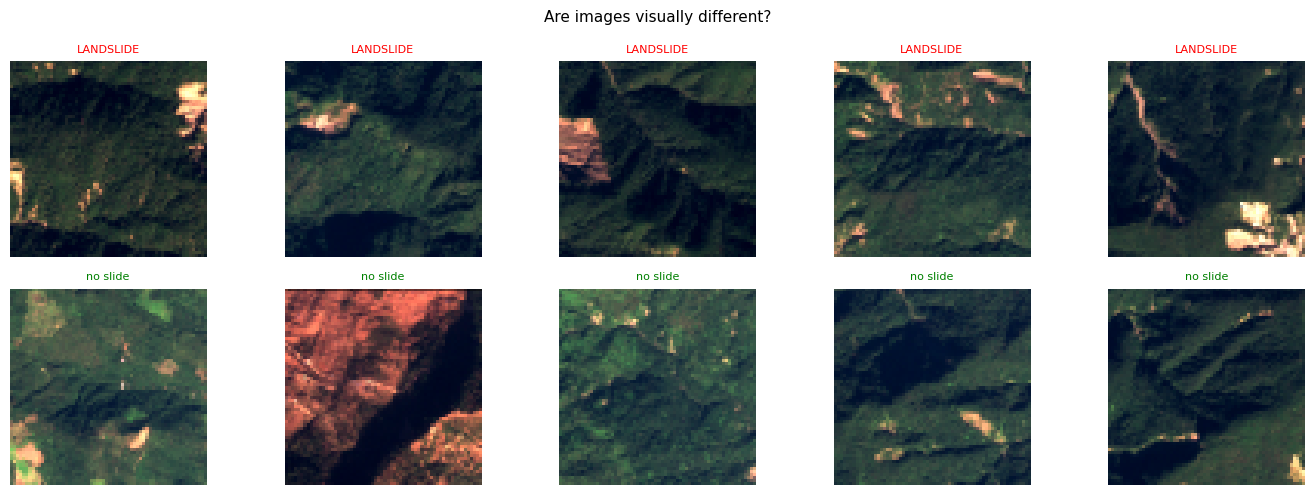

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Label distribution ─────────────────────────────────────────
print("=== LABEL CHECK ===")
print(f"y_train unique values : {np.unique(y_train_img, return_counts=True)}")
print(f"y_val   unique values : {np.unique(y_val_img,   return_counts=True)}")
print(f"y_train dtype         : {y_train_img.dtype}")
print(f"% landslide in train  : {y_train_img.mean()*100:.1f}%")

# ── 2. Image pixel sanity ─────────────────────────────────────────
print("\n=== IMAGE CHECK ===")
print(f"images dtype  : {X_train_img.dtype}")
print(f"images min    : {X_train_img.min():.4f}")
print(f"images max    : {X_train_img.max():.4f}")
print(f"images mean   : {X_train_img.mean():.4f}")
print(f"NaN count     : {np.isnan(X_train_img).sum()}")
print(f"Inf count     : {np.isinf(X_train_img).sum()}")

# ── 3. Are images actually different from each other? ─────────────
print("\n=== IMAGE VARIANCE CHECK ===")
per_image_std = X_train_img.reshape(len(X_train_img), -1).std(axis=1)
print(f"Std per image — mean: {per_image_std.mean():.4f}  "
      f"min: {per_image_std.min():.4f}  max: {per_image_std.max():.4f}")
print(f"Images with std < 0.01 (near-blank): "
      f"{(per_image_std < 0.01).sum()}")

# ── 4. What does the model currently output? ──────────────────────
print("\n=== MODEL OUTPUT CHECK ===")
preds = cnn_model.predict(X_val_img[:20], verbose=0).flatten()
print(f"First 20 predictions : {np.round(preds, 4)}")
print(f"Are all predictions same? {np.allclose(preds, preds[0])}")

# ── 5. Show 5 landslide vs 5 non-landslide images ─────────────────
ls_idx    = np.where(y_train_img == 1)[0][:5]
no_ls_idx = np.where(y_train_img == 0)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes[0]):
    ax.imshow(X_train_img[ls_idx[i]])
    ax.set_title("LANDSLIDE", fontsize=8, color='red')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(X_train_img[no_ls_idx[i]])
    ax.set_title("no slide", fontsize=8, color='green')
    ax.axis('off')
plt.suptitle("Are images visually different?", fontsize=11)
plt.tight_layout(); plt.show()